# Scaling & Hyperparameter Tuning

![](https://i.ytimg.com/vi/b0L_2jKEbA4/maxresdefault.jpg)

In this notebook you will see a short example of how to scale your data and tune the hyperparameters of your models using grid or randomized search. Along the way you will use cross-validation to evaluate your models more reliably than a single train-test split allows.

We will use the well-known Titanic dataset. Since you have already worked through exploring, cleaning, and selecting features for modelling in another notebook, we skip that here and start from the **preprocessed data** from the logistic regression notebook.

## Learning Objectives

By the end of this notebook, you should be able to:

- Scale numerical features with standardization (`StandardScaler`) and normalization (`MinMaxScaler`), and explain when each is useful.
- Combine preprocessing and a model into a single scikit-learn `Pipeline`.
- Evaluate models with K-fold cross-validation instead of relying on one train-test split.
- Tune hyperparameters with `GridSearchCV` and `RandomizedSearchCV`, and compare the trade-offs between them.

In [1]:
# Import packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from timeit import default_timer as timer


from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

RSEED = 10

In [2]:
# Import data
df = pd.read_csv("data/titanic_preprocessed.csv")
df.head()

,Survived,Age,SibSp,Parch,Fare,male,Q,S
0,0,22.0,1,0,7.2500,1,0,1
1,1,38.0,1,0,71.2833,0,0,0
2,1,26.0,0,0,7.9250,0,0,1
3,1,35.0,1,0,53.1000,0,0,1
4,0,35.0,0,0,8.0500,1,0,1


In [3]:
# Check for missing data
df.isnull().sum()

Survived    0
Age         0
SibSp       0
Parch       0
Fare        0
male        0
Q           0
S           0
dtype: int64

## Train-Test Split

We define the target and predictors, then split the dataset into a train and a test set.

In [4]:
# Define predictors and target
y = df.Survived
X = df.drop("Survived", axis=1)

In [5]:
# Check X
X.head(2)

,Age,SibSp,Parch,Fare,male,Q,S
0,22.0,1,0,7.2500,1,0,1
1,38.0,1,0,71.2833,0,0,0


In [6]:
# Train-test-split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

---
## Feature Scaling

Often the input features of your model have different units which means that the variables also have different scales. While some model types (e.g. tree-based models like decision tree or random forest) are unaffected by the scale of numerical input variables, many machine learning algorithms including for example algorithms using distance measures (e.g. KNN, SVM) perform better when the input features are scaled to a specific range. 

The most popular techniques for scaling are **normalization** and **standardization**. 

Check the [link](https://machinelearningmastery.com/standardscaler-and-minmaxscaler-transforms-in-python/) for further info. 

![](assets/normalization_vs_standardization.png)

The original dataset contains observations with different value ranges across the two features.

The figure demonstrates two common feature scaling techniques:

* **Normalisation** rescales each feature so that all values fall within a fixed range between **0 and 1**. This preserves the relative relationships between observations while placing all features on the same scale.

* **Standardisation** transforms each feature so that it is **centered around zero** and scaled according to its variability. As a result, most observations lie close to the mean and the features become more comparable in scale.

The illustration emphasizes that both methods preserve the underlying structure of the data while changing the numerical scale of the features.


In [7]:
# Before we have a look at the different methods,
# we have to define which columns we want to scale.
col_scale = ["Age", "SibSp", "Parch", "Fare"]

### Data Standardization 

In order to standardize a dataset it is necessary to rescale the distribution of values so that the mean of observed values is 0 and the standard deviation is 1. You can think of it as subtracting the mean value or centring the data. 
Sklearn provides us for this case with the [Standard scaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

A value is standardized as follows: 

$ x_{scaled} = \frac{x – \mu}{\sigma}  $, where 

$ \mu = \frac{\sum{x}}{m} $ is the mean, where m is the number of observations

$ \sigma = \sqrt{ \frac{\sum{ (x – \mu)^2 }}{m}} $ is the standard deviation

In [8]:
# transformation with column transformer
scaling_transformation = ColumnTransformer(
    [("scaling", StandardScaler(), col_scale)], remainder="passthrough"
)

### Data Normalization

Normalizing the data means rescaling it from the original range so that all values lie within a new range of 0 to 1. We can do this with the [Min-Max Scaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) from sklearn. This scaler transforms each feature by scaling it to a given range (the default range is 0 to 1).

A value is normalized as follows:

$ x_{scaled} = \frac{x – x_{min}}{x_{max} – x_{min}} $

(The min and max values pertain to the feature being normalized, taken from your **train** dataset.)

### Exercise 1: Practice Round

Try normalizing the data yourself.

<details>
<summary>Show answer</summary>

Use `MinMaxScaler` exactly like `StandardScaler`: import it, then wrap it in a `ColumnTransformer` so only the numeric columns are scaled.

```python
from sklearn.preprocessing import MinMaxScaler

normalization_transformation = ColumnTransformer(
    [("scaling", MinMaxScaler(), col_scale)], remainder="passthrough"
)
```

`MinMaxScaler` rescales each column to the range 0 to 1 using the minimum and maximum it learns from the training data, while `remainder="passthrough"` leaves the remaining columns unchanged.
</details>

In [9]:
# Scaling with MinMaxScaler
# Try to scale you data with the MinMaxScaler() from sklearn.
# It follows the same syntax as the StandardScaler.
# Don't forget: you have to import the scaler at the top of your notebook.

from sklearn.preprocessing import MinMaxScaler
normalization_transformation = ColumnTransformer([("scaling", MinMaxScaler(), col_scale)], remainder="passthrough")

### Bonus Question

Do the standardized / normalized test values follow the same properties as the standardized / normalized train values?

That is: standardized values centered on 0 with a standard deviation of 1, and normalized values between 0 and 1.

<details>
<summary>Show answer</summary>

Not exactly. The scaler learns its parameters (the mean and standard deviation for standardization, the minimum and maximum for normalization) from the **training** data only, and then applies those same fixed parameters to the test data. So:

- The standardized **train** features have a mean of 0 and a standard deviation of 1 by construction, but the standardized **test** features only have a mean near 0 and a standard deviation near 1, not exactly.
- Normalized **train** values fall exactly within 0 to 1, but normalized **test** values can fall slightly outside that range if the test set contains values beyond the train minimum or maximum.

This is the intended behavior: fitting the scaler on the training data only prevents information from the test set leaking into preprocessing.
</details>

---
## Predictive Modelling

We will evaluate model performance in a quick and more reliable way using sklearn's [cross_val_score()](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html), which implements K-fold cross-validation. When we train a model on a single train-test split we only have one experiment. Can we really trust one experiment?

Think of [K-fold cross-validation](https://en.wikipedia.org/wiki/Cross-validation_(statistics)) as running K experiments and taking the average error. It is still not perfect, but it is more trustworthy than a single split that might turn out unusually good or bad by chance.

This raises the question of which value to use for K. Common values are between 5 and 10, and you also need to account for technical limits: dataset size, compute power, available memory, and time. Cross-validation takes a while on large datasets.

![](assets/cross_validation.png)

The dataset is first split into a **training set** and a **test set**. The test set is held aside and not used during training or model selection.

The training set is then divided into **5 folds**.

Cross-validation works by repeatedly training and validating the model:

* One fold is used as the **validation set**
* The remaining four folds are used as the **training set**
* The model is evaluated on the validation fold to produce one error value

This process is repeated **five times**, so that each fold is used as the validation set exactly once.

The final cross-validation error is calculated as the **average of the five error values**.

### KNN Classifier: Unscaled Data

In [10]:
# Fit and evaluate model without hyperparameter tuning using cross validation and unscaled data
knn_classifier = KNeighborsClassifier()
scores = cross_val_score(knn_classifier, X_train, y_train, cv=5, n_jobs=-1)

# Evaluation
print("Score (unscaled):", round(scores.mean(), 2))
print("Standard Deviation (unscaled):", round(scores.std(), 2))

Score (unscaled): 0.69
Standard Deviation (unscaled): 0.02


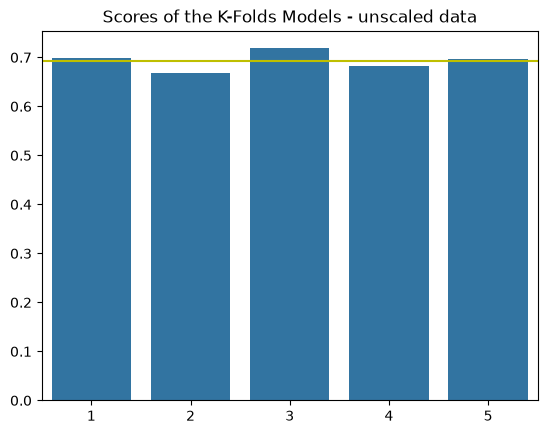

In [11]:
# plotting the scores and average score
plt.axhline(y=scores.mean(), color="y", linestyle="-")
sns.barplot(x=[1, 2, 3, 4, 5], y=scores).set_title(
    "Scores of the K-Folds Models - unscaled data"
);

Image description:
Output of the bar plot comparing each of the 5 models trained during cross-validation and corresponding to the results given in the previous cell. The values fluctuate between around 0.67 and 0.72, and all the bars are generally of very similar heights. There is a horizontal line at the value which is the mean of the scores, i.e. 0.69. The plot is titled 'Scores of the K-Folds Models - unscaled data'.
End of image description

### KNN Classifier: Scaled Data

In [12]:
# Fit and evaluate model without hyperparameter tuning using cross validation and scaled data
knn_classifier_scaled = Pipeline(
    [("scaling_trans", scaling_transformation), ("knn", KNeighborsClassifier())]
)
scores_scaled = cross_val_score(
    knn_classifier_scaled, X_train, y_train, cv=StratifiedKFold(5), n_jobs=-1
)

# Evaluation
print("Score (scaled):", round(scores_scaled.mean(), 2))
print("Standard Deviation (unscaled):", round(scores.std(), 2))

Score (scaled): 0.78
Standard Deviation (unscaled): 0.02


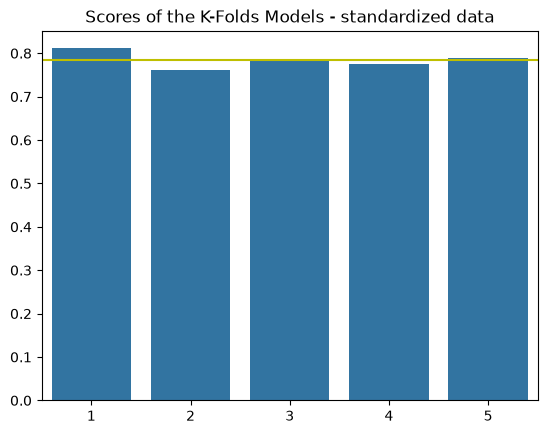

In [13]:
plt.axhline(y=scores_scaled.mean(), color="y", linestyle="-")
sns.barplot(x=[1, 2, 3, 4, 5], y=scores_scaled).set_title(
    "Scores of the K-Folds Models - standardized data"
);

You can see that the overall score has improved noticeably (in this run, about a 13% increase in the evaluation score), though the scores across folds are still fairly similar to each other. To show the effect of scaling more clearly, we will look at another classifier that is even more sensitive to it.

### SGD Classifier: Unscaled Data

The [SGD classifier](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html) (stochastic gradient descent classifier) implements a variety of classifiers. The model it fits is controlled by the `loss` parameter: by default it fits a linear support vector machine (SVM). We use it here to emphasise the importance of scaling, and set `loss="log_loss"` so the model becomes a logistic regression trained with stochastic gradient descent.

In [14]:
# Fit and evaluate model without hyperparameter tuning using cross validation and unscaled data
sgd_classifier = SGDClassifier(random_state=RSEED, loss="log_loss")
scores = cross_val_score(
    sgd_classifier, X_train, y_train, cv=StratifiedKFold(5), n_jobs=-1
)

# Evaluation
print("Score (unscaled):", round(scores.mean(), 2))
print("Standard Deviation (unscaled):", round(scores.std(), 2))

Score (unscaled): 0.71
Standard Deviation (unscaled): 0.05


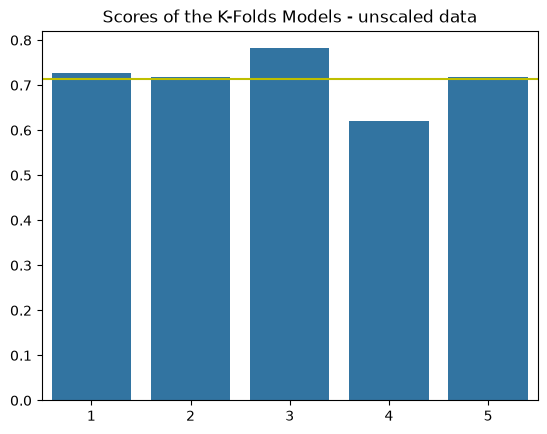

In [15]:
# plotting the scores and average score
plt.axhline(y=scores.mean(), color="y", linestyle="-")
sns.barplot(x=[1, 2, 3, 4, 5], y=scores).set_title(
    "Scores of the K-Folds Models - unscaled data"
);

The validation error varies a lot across the different folds of the data (from around 0.5 to a high of almost 0.8).

### SGD Classifier: Scaled Data

In [16]:
# Fit and evaluate model without hyperparameter tuning using cross validation and scaled data
sgd_classifier_scaled = Pipeline(
    [
        ("scaling_trans", scaling_transformation),
        ("sgd", SGDClassifier(random_state=RSEED, loss="log_loss")),
    ]
)

scores_scaled = cross_val_score(
    sgd_classifier_scaled, X_train, y_train, cv=StratifiedKFold(5), n_jobs=-1
)

# Evaluation
print("Score (scaled):", round(scores_scaled.mean(), 2))
print("Standard Deviation (unscaled):", round(scores_scaled.std(), 2))

Score (scaled): 0.78
Standard Deviation (unscaled): 0.02


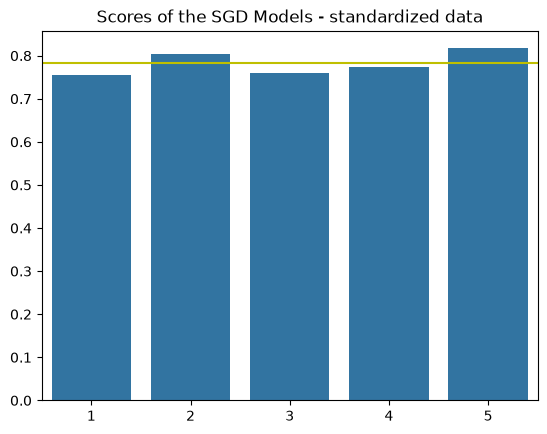

In [17]:
plt.axhline(y=scores_scaled.mean(), color="y", linestyle="-")
sns.barplot(x=[1, 2, 3, 4, 5], y=scores_scaled).set_title(
    "Scores of the SGD Models - standardized data"
);

Besides the clearly better overall performance, an important effect of scaling visible here is that the validation error no longer varies as much as it used to, with most values now closer to the 0.8 mark.

### Exercise 2: Practice Round

Try the KNN classifier with the normalized data.

<details>
<summary>Show answer</summary>

Reuse the normalization transformer from Exercise 1 inside a `Pipeline`, just as we did for the standardized KNN model, then evaluate it with cross-validation:

```python
knn_normalized = Pipeline(
    [("scaling_trans", normalization_transformation), ("knn", KNeighborsClassifier())]
)
scores_norm = cross_val_score(
    knn_normalized, X_train, y_train, cv=StratifiedKFold(5), n_jobs=-1
)
print("Score (normalized):", round(scores_norm.mean(), 2))
```

For KNN the results from normalization and standardization are usually very close, since both put the features on a comparable scale. What matters most is that the data is scaled at all, because KNN relies on distances between points.
</details>

In [18]:
# Train model using the MinMaxScaler data you scaled in ex1.

# It follows the same syntax as the StandardScaler.

knn_normalized = Pipeline([
    ("scaling_trans", normalization_transformation),
    ("knn", KNeighborsClassifier())
])

scores_morm = cross_val_score(knn_normalized, X_train, y_train, cv=StratifiedKFold(5), n_jobs=-1)
print("Score (normalized):", round(scores_morm.mean(), 2))

Score (normalized): 0.79


---
## Hyperparameter Tuning

Most models have many hyperparameters, and the best values differ from one dataset to another. The same is true for the regularization hyperparameters we saw earlier, which are usually chosen by trial and error. So how do we find the parameter values that work best for our data?

#### GridSearchCV

[Grid search](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) is a tuning technique that searches for the best hyperparameter values. It performs an exhaustive search over a predefined parameter space using cross-validation (hence the **CV** suffix), evaluating every possible combination in the search space to find and return the best one.

This becomes time-consuming when there are many hyperparameters and the search space is large. For example, with k=5 and 2 parameters taking 2 and 3 values respectively (6 combinations), GridSearchCV runs 30 modelling steps just to find the best values for those two parameters.

![](assets/grid_search_cv.png)

The process evaluates multiple combinations of hyperparameters to identify the model configuration that performs best.

In this example, two hyperparameters are considered:

* parameter **a** with possible values **1, 2, and 3**
* parameter **b** with possible values **1 and 2**

This produces **6 possible hyperparameter combinations**.

For each combination, **5-fold cross-validation** is performed:

* the training data is divided into 5 folds
* the model is trained and validated 5 times
* the performance scores are averaged to obtain a cross-validation score for that parameter combination

This process is repeated for all 6 combinations.

In total, **30 models are trained (6 × 5)**.

The parameter combination with the best average validation performance is selected as the final model configuration.


In [19]:
# what hyperparameters does KNN have?
knn_classifier_scaled.get_params()

{'memory': None,
 'steps': [('scaling_trans',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('scaling', StandardScaler(),
                                    ['Age', 'SibSp', 'Parch', 'Fare'])])),
  ('knn', KNeighborsClassifier())],
 'transform_input': None,
 'verbose': False,
 'scaling_trans': ColumnTransformer(remainder='passthrough',
                   transformers=[('scaling', StandardScaler(),
                                  ['Age', 'SibSp', 'Parch', 'Fare'])]),
 'knn': KNeighborsClassifier(),
 'scaling_trans__n_jobs': None,
 'scaling_trans__remainder': 'passthrough',
 'scaling_trans__sparse_threshold': 0.3,
 'scaling_trans__transformer_weights': None,
 'scaling_trans__transformers': [('scaling',
   StandardScaler(),
   ['Age', 'SibSp', 'Parch', 'Fare'])],
 'scaling_trans__verbose': False,
 'scaling_trans__verbose_feature_names_out': True,
 'scaling_trans__scaling': StandardScaler(),
 'scaling_trans__scaling__copy': True,
 'scaling_trans__scali

In [20]:
# Defining parameter grid (as dictionary)
param_grid = {
    "knn__n_neighbors": [2, 4, 3, 5, 10],  # this actually defines the model you use
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2, 3],
}

# Instantiate gridsearch and define the metric to optimize
gs = GridSearchCV(
    knn_classifier_scaled, param_grid, scoring="accuracy", cv=5, verbose=1, n_jobs=-1
)

# Fit gridsearch object to data.. also lets see how long it takes
start = timer()
gs.fit(X_train, y_train)
end = timer()
gs_time = end - start

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [21]:
gs_time

1.677071916999921

In [22]:
# Best score
print("Best score:", round(gs.best_score_, 3))

# Best parameters
print("Best parameters:", gs.best_params_)

Best score: 0.786
Best parameters: {'knn__n_neighbors': 5, 'knn__p': 3, 'knn__weights': 'uniform'}


In [23]:
# we will do this at least twice.. according to DRY we should write a function
def print_pretty_summary(name, best_model, y_test, y_pred_test):
    print(name)
    print("=======================")
    print("n_neighbors: {}".format(best_model.steps[-1][1].n_neighbors))
    print("weights: {}".format(best_model.steps[-1][1].weights))
    print("p: {}".format(best_model.steps[-1][1].p))
    print("algorithm: {}".format(best_model.steps[-1][1].algorithm))

    accuracy = accuracy_score(y_test, y_pred_test)
    print("Test accuracy: {:2f}".format(accuracy))
    return accuracy

In [24]:
knn_best = gs.best_estimator_
knn_best

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaling_trans', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Age','SibSp','Parch',...,'male','Q','S']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaling', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified i

In [25]:
# Assigning the fitted KNNClassifier model with best parameter combination to a new variable knn_best
knn_best = gs.best_estimator_

# Making predictions on the test set
y_pred_test = knn_best.predict(X_test)
# Let us print out the performance of our model on the test set.
knn_accuracy = print_pretty_summary(
    "KNNClassifier model", knn_best, y_test, y_pred_test
)

KNNClassifier model
n_neighbors: 5
weights: uniform
p: 3
algorithm: auto
Test accuracy: 0.764045


#### RandomizedSearchCV

As an alternative to grid search we can use sklearn's [RandomizedSearchCV()](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html). Random search does not try every possible combination in the search space; instead it randomly picks and evaluates a set number of parameter combinations.

In [26]:
# Define parameter grid for randomized search
param_grid = {
    "knn__n_neighbors": [2, 4, 3, 5, 10],  # this actually defines the model you use
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2, 3],
}
# Instantiate random search and define the metric to optimize
rs = RandomizedSearchCV(
    knn_classifier_scaled,
    param_grid,
    scoring="accuracy",
    cv=5,
    verbose=5,
    n_jobs=-1,
    random_state=RSEED,
)

# Fit randomized search object to data
start = timer()
rs.fit(X_train, y_train)
end = timer()
rgs_time = end - start

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END knn__n_neighbors=5, knn__p=2, knn__weights=uniform;, score=0.811 total time=   0.0s
[CV 2/5] END knn__n_neighbors=5, knn__p=2, knn__weights=uniform;, score=0.761 total time=   0.0s
[CV 3/5] END knn__n_neighbors=5, knn__p=2, knn__weights=uniform;, score=0.782 total time=   0.0s
[CV 4/5] END knn__n_neighbors=5, knn__p=2, knn__weights=uniform;, score=0.775 total time=   0.0s
[CV 5/5] END knn__n_neighbors=5, knn__p=2, knn__weights=uniform;, score=0.789 total time=   0.0s
[CV 1/5] END knn__n_neighbors=4, knn__p=1, knn__weights=distance;, score=0.769 total time=   0.0s
[CV 2/5] END knn__n_neighbors=4, knn__p=1, knn__weights=distance;, score=0.746 total time=   0.0s
[CV 4/5] END knn__n_neighbors=4, knn__p=1, knn__weights=distance;, score=0.754 total time=   0.0s
[CV 5/5] END knn__n_neighbors=4, knn__p=1, knn__weights=distance;, score=0.775 total time=   0.0s
[CV 3/5] END knn__n_neighbors=4, knn__p=1, knn__weights=distan

In [27]:
# Best score
print("Best score:", round(rs.best_score_, 3))

# Best parameters
print("Best parameters:", rs.best_params_)

Best score: 0.783
Best parameters: {'knn__weights': 'uniform', 'knn__p': 2, 'knn__n_neighbors': 5}


In [28]:
# Assigning the fitted KNNClassifier model with best parameter combination to a new variable knn_best
knn_best_rs = rs.best_estimator_

# Making predictions on the test set
y_pred_test_rs = knn_best_rs.predict(X_test)


# Let us print out the performance of our model on the test set.
rknn_accuracy = print_pretty_summary(
    "KNNClassifier model (randomizedGSCV)", knn_best_rs, y_test, y_pred_test_rs
)

KNNClassifier model (randomizedGSCV)
n_neighbors: 5
weights: uniform
p: 2
algorithm: auto
Test accuracy: 0.769663


In [29]:
print(f"Grid search took {gs_time} seconds to run with accuracy: {knn_accuracy:f}")
print(
    f"Randomized Grid search took {rgs_time} seconds to run with accuracy: {rknn_accuracy:f}"
)

Grid search took 1.677071916999921 seconds to run with accuracy: 0.764045
Randomized Grid search took 0.0880408749999333 seconds to run with accuracy: 0.769663


This is an educational example: keep in mind that more data means longer training times.